In [1]:
import os
os.chdir("../dgl_ptm/")

import sys
import dgl_ptm
import networkx as nx

os.environ["DGLBACKEND"] = "pytorch"
import torch

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [2]:
model = dgl_ptm.SVEIRModel(model_identifier='seir_test')
seed = 42

In [76]:
model.set_model_parameters(**{
    'number_agents': 200,
    'seed':seed,
    'spatial': True,
    'spatial_creation_args':{
        "method": "custom_import",
        "path": "ghana_grid.npy",
        "properties": {"population": 0}
    },
    'spatial_assignment_args':{'method':"property",'property':"population"},
    'initial_graph_type': 'barabasi-albert',
    'initial_graph_args': {'seed': seed, 'new_node_edges':5},
    'device': 'cpu',
    'step_target':5,
    'steering_parameters': {
        'npath':'./agent_data.zarr',
        'epath':'./edge_data',
        'ndata':[[],['initial_only',[]]],
        'edata':None,
        'mode':'w',
        'proximity_decay_rate':0.05,
        'truncation_weight':1e-10,
        'infection_probability':0.3,
        'incubation_period':5,
        'infections_period':3,
        'initial_infected_proportion':0.03,
        'step_type':'seir'
    }
})

In [77]:
model.initialize_model()
print()
print(model.config)

Model torch seed set to 42
Using seed 42 for network creation with 5 edges requested.
200 agents initialized on cpu device

model_identifier='seir_test' description='' device='cpu' seed=42 number_agents=200 spatial=True spatial_creation_args=GridCreationParams(method='custom_import', x=10, y=10, properties={'population': 0}, path='ghana_grid.npy') spatial_assignment_args=GridAssignmentParams(method='property', property='population', path=None) initial_graph_type='barabasi-albert' initial_graph_args=InitialGraphArgs(seed=42, new_node_edges=5) step_target=5 steering_parameters=SteeringParamsSVEIR(npath='seir_test/agent_data.zarr', epath='seir_test/edge_data', ndata=[[], ['initial_only', []]], edata=None, mode='w', infection_probability=0.3, incubation_period=5, infections_period=3, initial_infected_proportion=0.03, truncation_weight=1e-10, proximity_decay_rate=0.05, step_type='seir', data_collection_period=1, data_collection_list=None) checkpoint_period=10 milestones=None


In [78]:
dist = []
u, v = model.graph.edges()
x_u = model.graph.ndata['x'][u]
y_u = model.graph.ndata['y'][u]
x_v = model.graph.ndata['x'][v]
y_v = model.graph.ndata['y'][v]
distance = torch.sqrt((x_u - x_v)**2 + (y_u - y_v)**2)

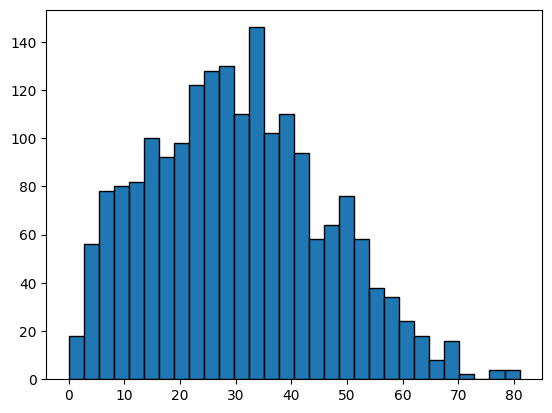

In [79]:
plt.hist(distance, bins=30, edgecolor='k')
plt.show()

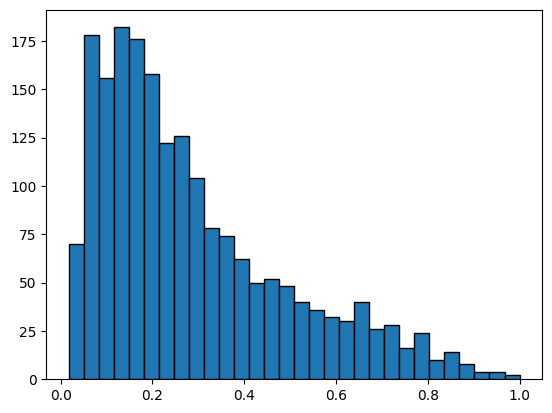

In [80]:
weights = model.graph.edata["weight"]
plt.hist(weights, bins=30, edgecolor='k')
plt.show()

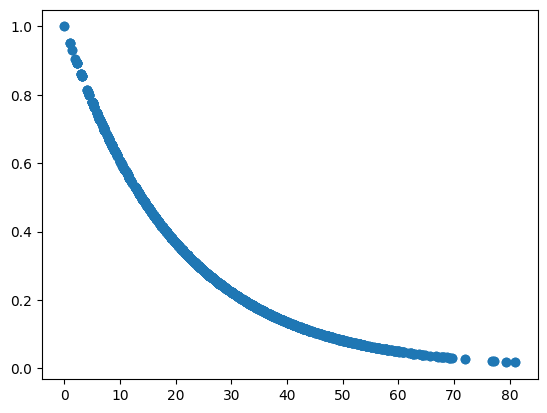

In [81]:
plt.scatter(distance, weights)
plt.show()

In [82]:
# nx.draw(model.graph.to_networkx())

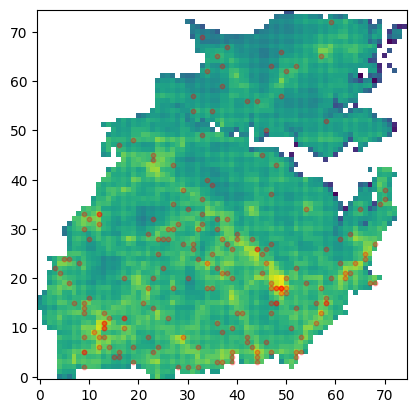

In [83]:
plt.imshow(model.grid_environment.get_slice("population"), norm=LogNorm())
plt.gca().invert_yaxis()
plt.scatter(model.graph.ndata['x'], model.graph.ndata['y'], c="red", s=10, alpha=0.3)
plt.show()

In [52]:
model.run()

NotImplementedError: run method is not implemented for this class.

### Results

In [ ]:
import zarr
import os
zarr_file_one = zarr.open('/Users/victoria/Documents/Scripts/Python/DGL-PTM/Sensitivity_Analysis/data_mode_A/agent_data.zarr', mode='r')
zarr_file_two = zarr.open('/Users/victoria/Documents/Scripts/Python/DGL-PTM/Sensitivity_Analysis/data_mode_B/agent_data.zarr', mode='r')
zarr_file_three = zarr.open('/Users/victoria/Documents/Scripts/Python/DGL-PTM/Sensitivity_Analysis/data_mode_B/agent_data_initial.zarr', mode='r')
zarr_file_four = zarr.open('/Users/victoria/Documents/Scripts/Python/DGL-PTM/Sensitivity_Analysis/SA_test/agent_data.zarr', mode='r')

#print(zarr_file_one.tree())
#print(zarr_file_two.tree())
#print(zarr_file_three.tree())

#attributes=os.listdir('/Users/victoria/Documents/Scripts/Python/DGL-PTM/Sensitivity_Analysis/test_SA/agent_data.zarr')
#attributes = [item for item in attributes if item not in ['.zattrs','.zmetadata','.zgroup']]
#attributes = {key: None for key in attributes}
#print(attributes)
#print(zarr_file_one['wealth'][0:2])
#print(zarr_file_two['wealth'][0:2])

#print(zarr_file_one['alpha'][0:2])
#print(zarr_file_two['alpha'][0:2])

#format: zarr_file['property'][agent(s),timestep(s)]
print(zarr_file_four['wealth'][0:20,0])

#Unnecessary:'a_table','m','tec','gamma','cost','zeros','ones', 'total_weight', "disposable_wealth"
#One-Time: 'alpha',"lambda","sigma","sensitivity"
#Every-Time: 'degree','i_a','income','net_trade', 'tech_index','theta', 'wealth', 'wealth_consumption','weighted_degree'


In [ ]:
ndata = ['all']
ndata = ['all_except',['a_table','m','tec','gamma','cost','zeros','ones', 'total_weight', "disposable_wealth"]]
ndata = [['all_except',['a_table','m','tec','gamma','cost','zeros','ones', 'total_weight', "disposable_wealth"]], ["initial_only",['alpha',"lambda","sigma","sensitivity"]]]
ndata = [['degree','i_a','income','net_trade', 'tech_index','theta', 'wealth', 'wealth_consumption','weighted_degree'], ["initial_only",['alpha',"lambda","sigma","sensitivity"]]]

timestep = 10

if ndata == ['all']:
    ndata = list(attributes.keys())
elif ndata[0] == 'all_except':
    ndata = list(attributes.keys() - ndata[1])
elif sum(1 for item in ndata if isinstance(item, list)) > 1:
    ndata_list = ndata
    initial_only=[]
    for specification in ndata_list:
        if specification == ['all']:
            raise ValueError('Use of "all" is not compatible with multiple data collection specification lists.')
        elif specification[0] == 'all_except':
            ndata = list(attributes.keys() - specification[1])
        elif specification[0] == 'initial_only':
            if timestep == 0:
                initial_only = specification[1]
        else:
            ndata = specification
    ndata=ndata+initial_only


print(ndata)
